<a href="https://colab.research.google.com/github/aendris18/Frist-class/blob/main/multi%20class%20intrussion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================================
# STEP 1: Import Required Libraries
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================================================================
# STEP 2: Load and Explore the Dataset
# ============================================================================

# Load the UNSW-NB15 dataset
# Download from: https://www.unsw.adfa.edu.au/unsw-canberra-cyber/cybersecurity/ADFA-NB15-Datasets/
# For this example, we'll use the training and testing CSV files

# Try to load the dataset (you need to download it first)
try:
    # Option 1: If you have the UNSW-NB15 dataset
    df_train = pd.read_csv("C:/Users/Owner/Desktop/archive (1)/UNSW_NB15_training-set.csv")
    df_test = pd.read_csv("C:/Users/Owner/Desktop/archive (1)/UNSW_NB15_testing-set.csv")
    df = pd.concat([df_train, df_test], ignore_index=True)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    # Option 2: Generate synthetic UNSW-NB15-like data for demonstration
    print("Dataset not found. Generating synthetic UNSW-NB15-like data for demonstration...")
    np.random.seed(42)
    n_samples = 10000
    n_features = 40

    # Generate feature columns
    feature_names = [f'feature_{i}' for i in range(n_features)]

    # Generate synthetic data
    data = np.random.randn(n_samples, n_features)

    # Create binary labels (normal vs attack)
    labels = np.random.choice(['Normal', 'Attack'], size=n_samples, p=[0.4, 0.6])

    # Create multi-class labels (attack categories)
    attack_types = ['Normal', 'DoS', 'Reconnaissance', 'Exploits', 'Fuzzers',
                    'Worms', 'Backdoor', 'Shellcode', 'Generic']
    labels_multi = np.random.choice(attack_types, size=n_samples,
                                    p=[0.4, 0.15, 0.12, 0.1, 0.08, 0.05, 0.04, 0.03, 0.03])

    # Create DataFrame
    df = pd.DataFrame(data, columns=feature_names)
    df['label'] = labels
    df['attack_cat'] = labels_multi

    print(f"Generated {n_samples} synthetic samples with {n_features} features")

# Display basic information about the dataset
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Dataset Shape: {df.shape}")
print(f"Number of features: {df.shape[1] - 2}")  # Excluding 'label' and 'attack_cat'
print(f"Number of samples: {df.shape[0]}")
print("\nFeature Data Types:")
print(df.dtypes.value_counts())

# Display first few rows
print("\n" + "="*60)
print("FIRST 5 ROWS OF THE DATASET")
print("="*60)
print(df.head())

# Display statistical summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

Dataset not found. Generating synthetic UNSW-NB15-like data for demonstration...
Generated 10000 synthetic samples with 40 features

DATASET INFORMATION
Dataset Shape: (10000, 42)
Number of features: 40
Number of samples: 10000

Feature Data Types:
float64    40
object      2
Name: count, dtype: int64

FIRST 5 ROWS OF THE DATASET
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.496714  -0.138264   0.647689   1.523030  -0.234153  -0.234137   
1   0.738467   0.171368  -0.115648  -0.301104  -1.478522  -0.719844   
2  -0.219672   0.357113   1.477894  -0.518270  -0.808494  -0.501757   
3   0.791032  -0.909387   1.402794  -1.401851   0.586857   2.190456   
4  -0.974682   0.787085   1.158596  -0.820682   0.963376   0.412781   

   feature_6  feature_7  feature_8  feature_9  ...  feature_32  feature_33  \
0   1.579213   0.767435  -0.469474   0.542560  ...   -0.013497   -1.057711   
1  -0.460639   1.057122   0.343618  -1.763040  ...   -0.035826    1.564644   
2   0.9

In [3]:
# ============================================================================
# STEP 3: Data Preprocessing
# ============================================================================

print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Separate features and target
X = df.drop(['label', 'attack_cat'], axis=1)
y_binary = df['label']  # Binary classification
y_multi = df['attack_cat']  # Multi-class classification

print(f"\nFeatures shape: {X.shape}")
print(f"Binary labels shape: {y_binary.shape}")
print(f"Multi-class labels shape: {y_multi.shape}")

# Encode labels
label_encoder = LabelEncoder()
y_binary_encoded = label_encoder.fit_transform(y_binary)
y_multi_encoded = label_encoder.fit_transform(y_multi)

print(f"\nBinary Labels: {np.unique(y_binary_encoded)}")
print(f"Multi-class Labels: {np.unique(y_multi_encoded)}")
print(f"Multi-class Label Counts: {np.unique(y_multi, return_counts=True)}")

# Split the data
X_train, X_test, y_train_binary, y_test_binary, y_train_multi, y_test_multi = train_test_split(
    X, y_binary_encoded, y_multi_encoded, test_size=0.2, random_state=42, stratify=y_multi_encoded
)

print(f"\nTrain/Test Split:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling completed!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


DATA PREPROCESSING

Missing Values:
0

Features shape: (10000, 40)
Binary labels shape: (10000,)
Multi-class labels shape: (10000,)

Binary Labels: [0 1]
Multi-class Labels: [0 1 2 3 4 5 6 7 8]
Multi-class Label Counts: (array(['Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal',
       'Reconnaissance', 'Shellcode', 'Worms'], dtype=object), array([ 369, 1513, 1023,  787,  323, 4007, 1206,  309,  463]))

Train/Test Split:
Training samples: 8000
Testing samples: 2000

Feature Scaling completed!
X_train_scaled shape: (8000, 40)
X_test_scaled shape: (2000, 40)



EXPLORATORY DATA ANALYSIS


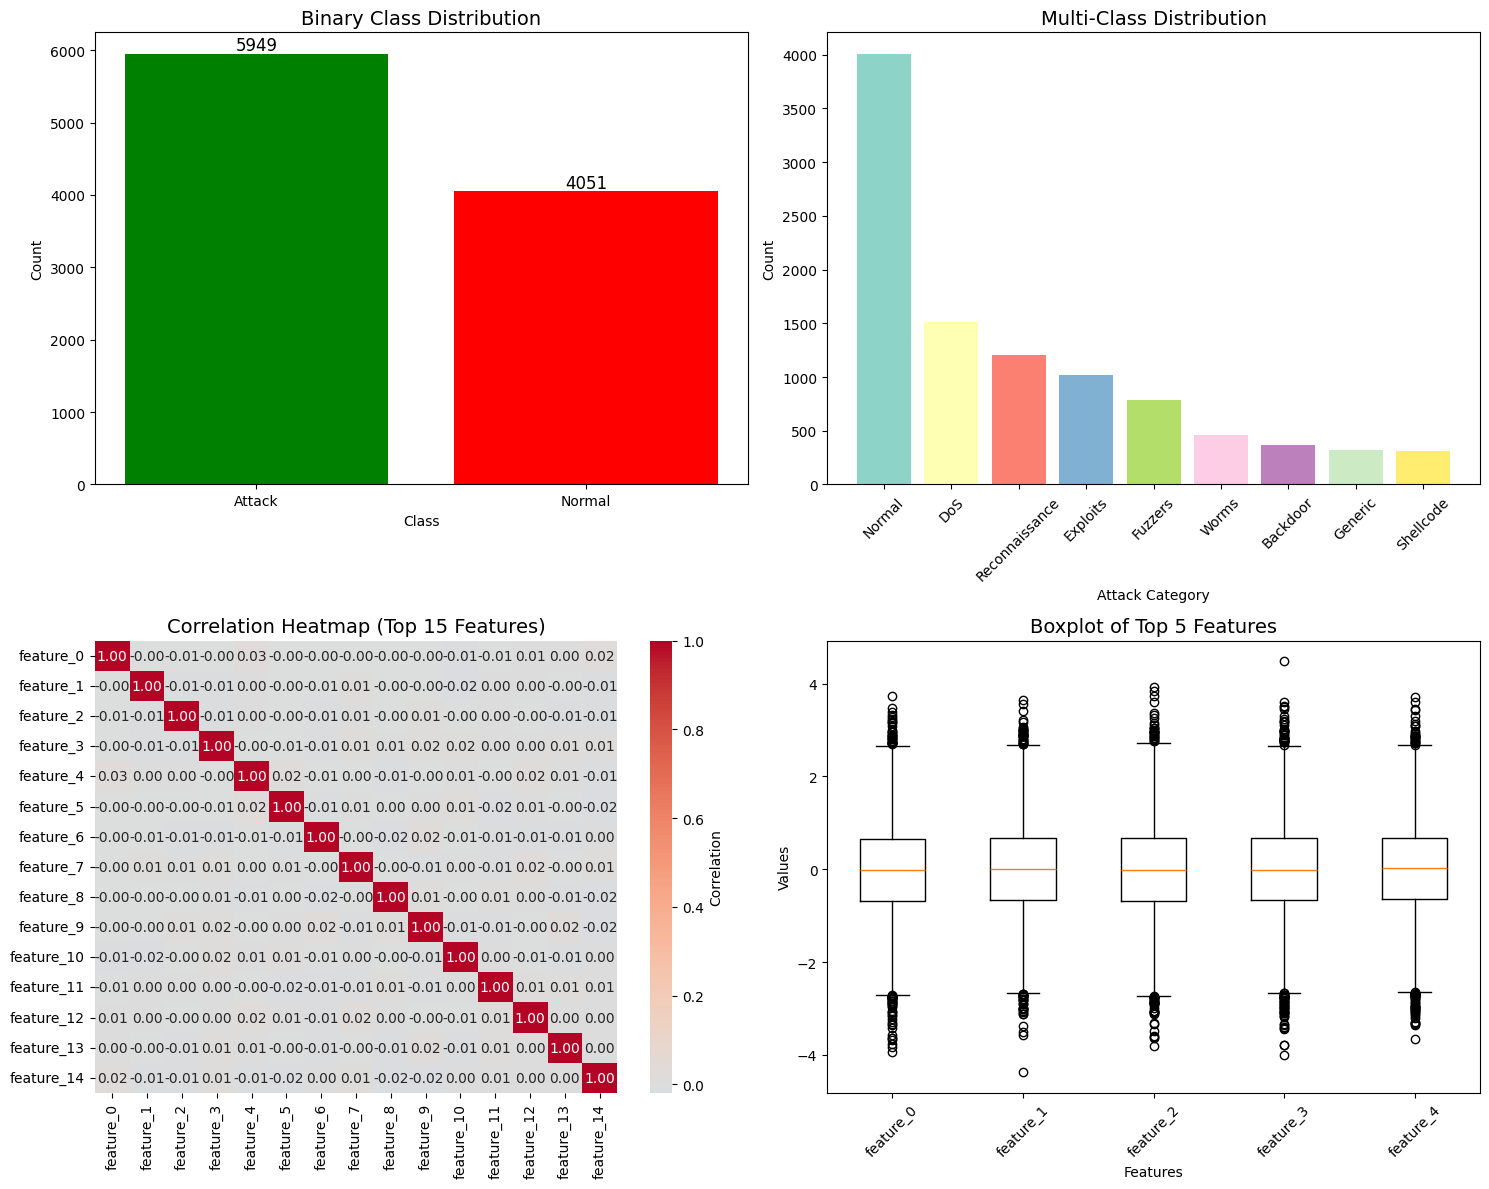

Visualizations displayed successfully!


In [4]:
# ============================================================================
# STEP 4: Visualization and EDA
# ============================================================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of labels
ax1 = axes[0, 0]
label_counts = pd.Series(y_binary).value_counts()
ax1.bar(label_counts.index, label_counts.values, color=['green', 'red'])
ax1.set_title('Binary Class Distribution', fontsize=14)
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    ax1.text(i, v + 50, str(v), ha='center', fontsize=12)

# 2. Multi-class distribution
ax2 = axes[0, 1]
multi_counts = pd.Series(y_multi).value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(multi_counts)))
ax2.bar(multi_counts.index, multi_counts.values, color=colors)
ax2.set_title('Multi-Class Distribution', fontsize=14)
ax2.set_xlabel('Attack Category')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

# 3. Correlation heatmap (top 15 features)
ax3 = axes[1, 0]
correlation_matrix = X.iloc[:, :15].corr()
sns.heatmap(correlation_matrix, ax=ax3, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
ax3.set_title('Correlation Heatmap (Top 15 Features)', fontsize=14)

# 4. Boxplot of top 5 features
ax4 = axes[1, 1]
top_features = X.columns[:5]
data_to_plot = [X[col].values for col in top_features]
ax4.boxplot(data_to_plot, labels=top_features)
ax4.set_title('Boxplot of Top 5 Features', fontsize=14)
ax4.set_xlabel('Features')
ax4.set_ylabel('Values')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Visualizations displayed successfully!")

In [ ]:
# ============================================================================
# STEP 5: Traditional Machine Learning Models (Binary Classification)
# ============================================================================

print("\n" + "="*60)
print("TRADITIONAL ML MODELS - BINARY CLASSIFICATION")
print("="*60)

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Helper function to train and evaluate models"""
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Print results
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cm}")

    return {'name': model_name, 'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'model': model}

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Store results
binary_results = []

# Evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    try:
        result = evaluate_model(model, X_train_scaled, X_test_scaled,
                               y_train_binary, y_test_binary, name)
        binary_results.append(result)
    except Exception as e:
        print(f"Error with {name}: {str(e)}")

# Compare results
print("\n" + "="*60)
print("MODEL COMPARISON - BINARY CLASSIFICATION")
print("="*60)
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in binary_results])
print(comparison_df.to_string(index=False))


TRADITIONAL ML MODELS - BINARY CLASSIFICATION

Training Logistic Regression...

Logistic Regression Results:
Accuracy: 0.5875
Precision: 0.3466
Recall: 0.5875
F1-Score: 0.4360
Confusion Matrix:
[[1175    3]
 [ 822    0]]

Training Decision Tree...

Decision Tree Results:
Accuracy: 0.5555
Precision: 0.5103
Recall: 0.5555
F1-Score: 0.5004
Confusion Matrix:
[[976 202]
 [687 135]]

Training Random Forest...

Random Forest Results:
Accuracy: 0.5870
Precision: 0.4150
Recall: 0.5870
F1-Score: 0.4366
Confusion Matrix:
[[1173    5]
 [ 821    1]]

Training Gradient Boosting...

Gradient Boosting Results:
Accuracy: 0.5840
Precision: 0.5259
Recall: 0.5840
F1-Score: 0.4612
Confusion Matrix:
[[1135   43]
 [ 789   33]]

Training SVM...

SVM Results:
Accuracy: 0.5770
Precision: 0.4802
Recall: 0.5770
F1-Score: 0.4499
Confusion Matrix:
[[1131   47]
 [ 799   23]]

Training KNN...

KNN Results:
Accuracy: 0.5370
Precision: 0.5197
Recall: 0.5370
F1-Score: 0.5232
Confusion Matrix:
[[814 364]
 [562 260]]

MO

In [ ]:
# ============================================================================
# STEP 6: Ensemble Learning Models
# ============================================================================

print("\n" + "="*60)
print("ENSEMBLE LEARNING MODELS")
print("="*60)

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Voting Classifier (Hard Voting)
voting_clf = VotingClassifier(
    estimators=[('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
                ('svm', SVC(kernel='rbf', probability=True, random_state=42))],
    voting='hard'
)

# 2. Voting Classifier (Soft Voting)
voting_clf_soft = VotingClassifier(
    estimators=[('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
                ('svm', SVC(kernel='rbf', probability=True, random_state=42))],
    voting='soft'
)

# 3. Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=[('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
                ('svm', SVC(kernel='rbf', probability=True, random_state=42))],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

ensemble_models = {
    'Hard Voting': voting_clf,
    'Soft Voting': voting_clf_soft,
    'Stacking': stacking_clf
}

ensemble_results = []

for name, model in ensemble_models.items():
    print(f"\n{'='*50}")
    print(f"Training {name} Ensemble...")
    try:
        result = evaluate_model(model, X_train_scaled, X_test_scaled,
                               y_train_binary, y_test_binary, name)
        ensemble_results.append(result)
    except Exception as e:
        print(f"Error with {name}: {str(e)}")

# Compare ensemble results
print("\n" + "="*60)
print("ENSEMBLE MODEL COMPARISON - BINARY CLASSIFICATION")
print("="*60)
ensemble_comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in ensemble_results])
print(ensemble_comparison_df.to_string(index=False))


DEEP LEARNING MODEL - BINARY CLASSIFICATION
Training Deep Learning Model...
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4994 - loss: 0.9495 - val_accuracy: 0.5694 - val_loss: 0.6874 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5414 - loss: 0.7885 - val_accuracy: 0.5669 - val_loss: 0.6872 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5455 - loss: 0.7387 - val_accuracy: 0.5756 - val_loss: 0.6836 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5530 - loss: 0.7081 - val_accuracy: 0.5863 - val_loss: 0.6803 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5672 - loss: 0.6884 - val_accuracy: 0.5863 - val_loss: 0.6789 - learning_rate: 0.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5844 - loss: 0.6785 - val_accuracy: 0.5919 - val_loss: 0.6770 - learning_rate: 0.0010
Epoch 7/50


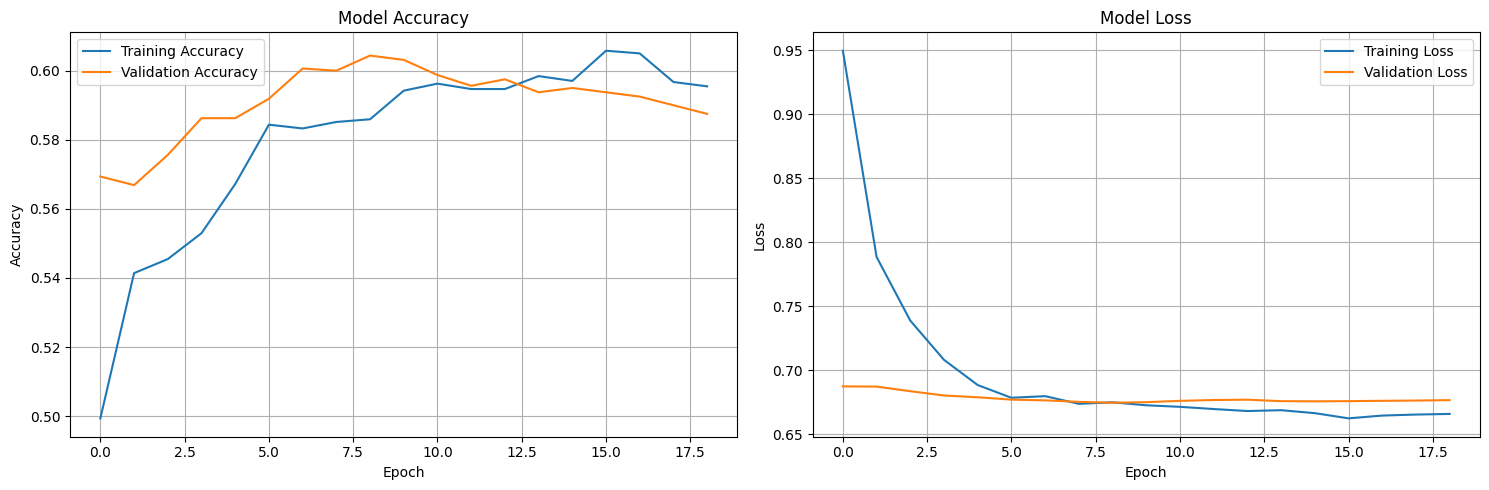

In [ ]:
# ============================================================================
# STEP 7: Deep Learning Model (Binary Classification)
# ============================================================================

print("\n" + "="*60)
print("DEEP LEARNING MODEL - BINARY CLASSIFICATION")
print("="*60)

# Convert labels to categorical
y_train_binary_cat = to_categorical(y_train_binary, 2)
y_test_binary_cat = to_categorical(y_test_binary, 2)

# Build the deep learning model
def create_dl_model(input_shape, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create and train the model
dl_model = create_dl_model(X_train_scaled.shape[1], 2)

# Early stopping
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

print("Training Deep Learning Model...")
history = dl_model.fit(
    X_train_scaled, y_train_binary_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate the model
y_pred_proba = dl_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)

accuracy = accuracy_score(y_test_binary, y_pred)
precision = precision_score(y_test_binary, y_pred)
recall = recall_score(y_test_binary, y_pred)
f1 = f1_score(y_test_binary, y_pred)

print("\nDeep Learning Model Results (Binary Classification):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Store results
dl_result = {
    'name': 'Deep Learning',
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'model': dl_model
}


MULTI-CLASS CLASSIFICATION

Random Forest - Multi-Class Classification:
Accuracy: 0.4000
Precision (weighted): 0.1603
Recall (weighted): 0.4000
F1-Score (weighted): 0.2289


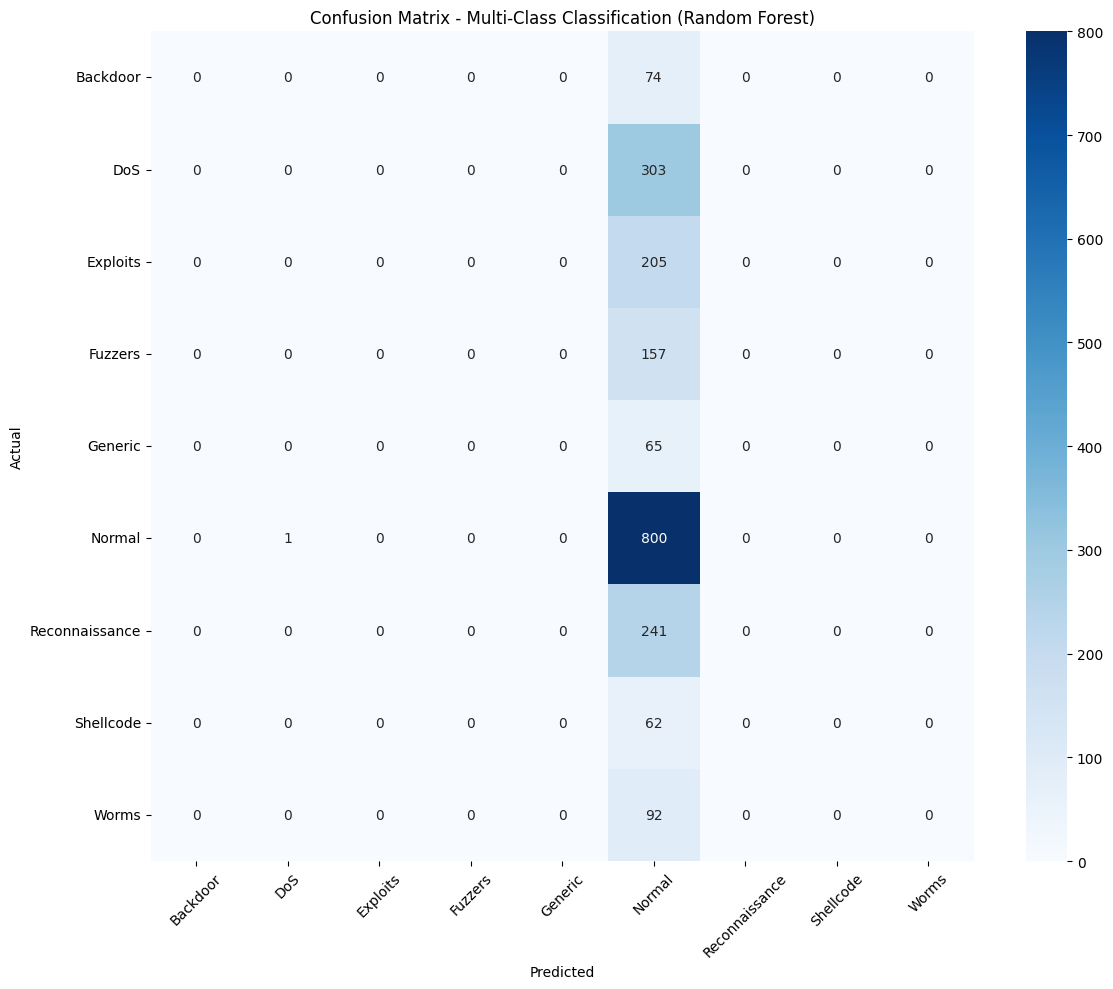


Deep Learning - Multi-Class Classification:
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1350 - loss: 2.7275 - val_accuracy: 0.2369 - val_loss: 2.0842 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2092 - loss: 2.2603 - val_accuracy: 0.3600 - val_loss: 1.9632 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2822 - loss: 2.0962 - val_accuracy: 0.3975 - val_loss: 1.8860 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3284 - loss: 1.9846 - val_accuracy: 0.4069 - val_loss: 1.8598 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3552 - loss: 1.9269 - val_accuracy: 0.4087 - val_loss: 1.8416 - learning_rate: 0.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3680 - loss: 1.8924 - val_accuracy: 0.4106 - val_loss: 1.8399 - learning_rate: 2.0000e-04
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================================================
# STEP 8: Multi-Class Classification
# ============================================================================

print("\n" + "="*60)
print("MULTI-CLASS CLASSIFICATION")
print("="*60)

# Convert multi-class labels to categorical
y_train_multi_cat = to_categorical(y_train_multi, len(np.unique(y_multi_encoded)))
y_test_multi_cat = to_categorical(y_test_multi, len(np.unique(y_multi_encoded)))

# Evaluate Random Forest on multi-class
print("\nRandom Forest - Multi-Class Classification:")
rf_multi = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15)
rf_multi.fit(X_train_scaled, y_train_multi)
y_pred_multi_rf = rf_multi.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test_multi, y_pred_multi_rf):.4f}")
print(f"Precision (weighted): {precision_score(y_test_multi, y_pred_multi_rf, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test_multi, y_pred_multi_rf, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test_multi, y_pred_multi_rf, average='weighted'):.4f}")

# Confusion Matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi_rf)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_multi), yticklabels=np.unique(y_multi))
plt.title('Confusion Matrix - Multi-Class Classification (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Deep Learning for Multi-Class
print("\nDeep Learning - Multi-Class Classification:")
dl_multi = create_dl_model(X_train_scaled.shape[1], len(np.unique(y_multi_encoded)))

history_multi = dl_multi.fit(
    X_train_scaled, y_train_multi_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

y_pred_proba_multi = dl_multi.predict(X_test_scaled)
y_pred_multi_dl = np.argmax(y_pred_proba_multi, axis=1)

print(f"Accuracy: {accuracy_score(y_test_multi, y_pred_multi_dl):.4f}")
print(f"Precision (weighted): {precision_score(y_test_multi, y_pred_multi_dl, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test_multi, y_pred_multi_dl, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test_multi, y_pred_multi_dl, average='weighted'):.4f}")

# Classification Report
print("\nClassification Report - Deep Learning (Multi-Class):")
print(classification_report(y_test_multi, y_pred_multi_dl,
                           target_names=np.unique(y_multi)))


COMPARATIVE ANALYSIS - ALL MODELS

Model Performance Comparison:
               name  accuracy  precision   recall       f1
      Deep Learning    0.5895   0.571429 0.004866 0.009650
           Stacking    0.5890   0.346921 0.589000 0.436653
        Soft Voting    0.5875   0.483714 0.587500 0.438630
Logistic Regression    0.5875   0.346557 0.587500 0.435953
      Random Forest    0.5870   0.414988 0.587000 0.436615
        Hard Voting    0.5855   0.505796 0.585500 0.445406
  Gradient Boosting    0.5840   0.525922 0.584000 0.461229
                SVM    0.5770   0.480203 0.577000 0.449869
      Decision Tree    0.5555   0.510323 0.555500 0.500438
                KNN    0.5370   0.519685 0.537000 0.523248


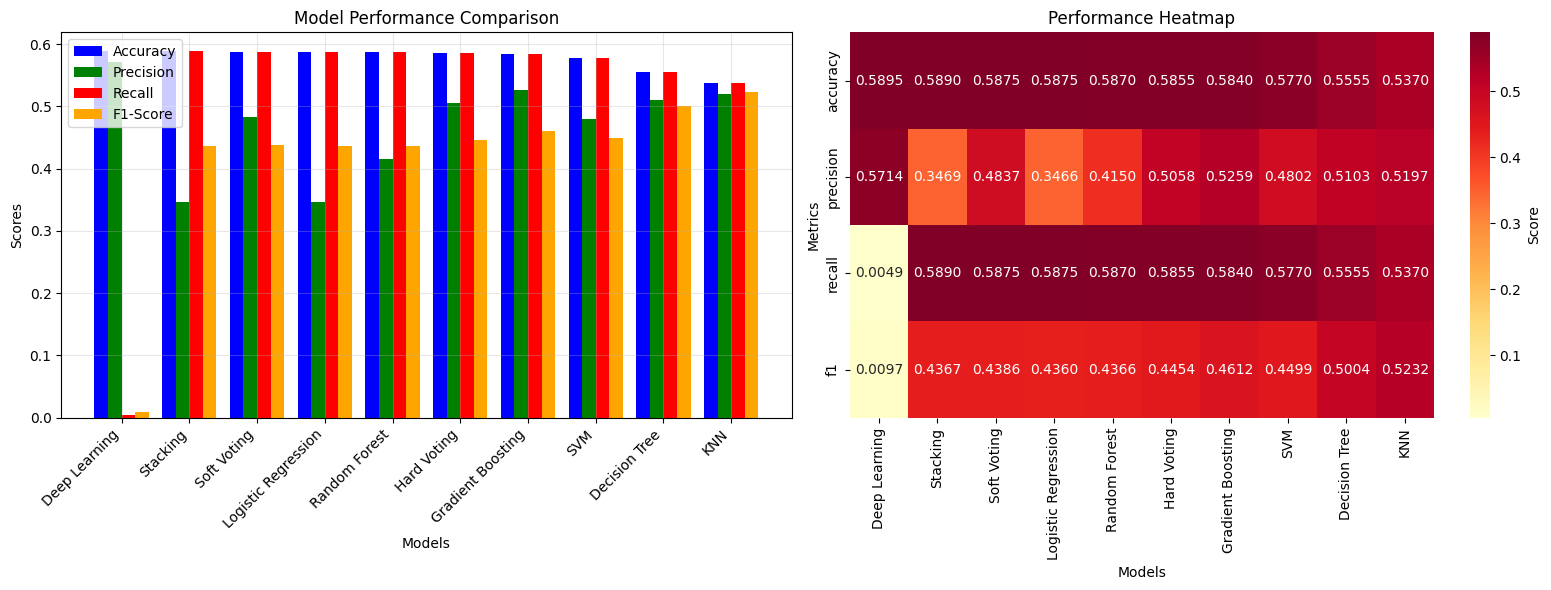


BEST PERFORMING MODEL: Deep Learning
Accuracy: 0.5895
Precision: 0.5714
Recall: 0.0049
F1-Score: 0.0097


In [ ]:
# ============================================================================
# STEP 9: Comparative Analysis
# ============================================================================

print("\n" + "="*60)
print("COMPARATIVE ANALYSIS - ALL MODELS")
print("="*60)

# Combine all results
all_results = binary_results + ensemble_results + [dl_result]

# Create comparison DataFrame
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in all_results])
comparison_df = comparison_df.sort_values('accuracy', ascending=False)

print("\nModel Performance Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualization of results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
ax1 = axes[0]
x = np.arange(len(comparison_df))
width = 0.2

ax1.bar(x - 1.5*width, comparison_df['accuracy'], width, label='Accuracy', color='blue')
ax1.bar(x - 0.5*width, comparison_df['precision'], width, label='Precision', color='green')
ax1.bar(x + 0.5*width, comparison_df['recall'], width, label='Recall', color='red')
ax1.bar(x + 1.5*width, comparison_df['f1'], width, label='F1-Score', color='orange')

ax1.set_xlabel('Models')
ax1.set_ylabel('Scores')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['name'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Heatmap
ax2 = axes[1]
heatmap_data = comparison_df[['accuracy', 'precision', 'recall', 'f1']].T
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=comparison_df['name'], yticklabels=heatmap_data.index,
            cbar_kws={'label': 'Score'}, ax=ax2)
ax2.set_title('Performance Heatmap')
ax2.set_xlabel('Models')
ax2.set_ylabel('Metrics')

plt.tight_layout()
plt.show()

# Print best model
best_model = comparison_df.iloc[0]
print(f"\n{'='*60}")
print(f"BEST PERFORMING MODEL: {best_model['name']}")
print(f"Accuracy: {best_model['accuracy']:.4f}")
print(f"Precision: {best_model['precision']:.4f}")
print(f"Recall: {best_model['recall']:.4f}")
print(f"F1-Score: {best_model['f1']:.4f}")
print("="*60)